In [23]:
import pandas as pd

permits = pd.read_csv('/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/data/processed/permits_clean.csv')
rent = pd.read_csv('/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/data/processed/zillow_rent_clean.csv')
employment = pd.read_csv('/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/data/processed/employment_clean.csv')
demographics = pd.read_csv('/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/data/processed/demographics_clean.csv')

print("PERMITS:")
print(f"Rows: {len(permits)}")
print(f"Unique neighborhoods: {permits['Neighborhood'].nunique()}")
print(f"Date range: {permits['Date'].min()} to {permits['Date'].max()}")
print(f"Months per neighborhood: {len(permits) / permits['Neighborhood'].nunique():.0f}")

print("\nRENT:")
print(f"Rows: {len(rent)}")
print(f"Unique neighborhoods: {rent['Neighborhood'].nunique()}")
print(f"Date range: {rent['Date'].min()} to {rent['Date'].max()}")
print(f"Months per neighborhood: {len(rent) / rent['Neighborhood'].nunique():.0f}")

print("\nEMPLOYMENT:")
print(f"Rows: {len(employment)}")
print(f"Date range: {employment['Date'].min()} to {employment['Date'].max()}")


print("\nDEMOGRAPHICS:")
print(f"Rows: {len(demographics)}")
print(f"Unique neighborhoods: {demographics['Neighborhood'].nunique()}")
print(f"Date range: {demographics['year'].min()} to {demographics['year'].max()}")
print(f"Years per neighborhood: {len(demographics) / demographics['Neighborhood'].nunique():.0f}")

PERMITS:
Rows: 1513
Unique neighborhoods: 22
Date range: 2020-01-31 to 2025-12-31
Months per neighborhood: 69

RENT:
Rows: 1870
Unique neighborhoods: 22
Date range: 2019-01-31 to 2026-01-31
Months per neighborhood: 85

EMPLOYMENT:
Rows: 85
Date range: 2019-01-31 to 2026-01-31

DEMOGRAPHICS:
Rows: 110
Unique neighborhoods: 22
Date range: 2019 to 2023
Years per neighborhood: 5


In [41]:
master = pd.read_csv('/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/data/processed/master.csv')

print(f"Shape: {master.shape}")
print(f"\nDtypes:\n{master.dtypes}")
print(f"\nMissing values:\n{master.isnull().sum()}")
print(f"\nDate range: {master['Date'].min()} to {master['Date'].max()}")
print(f"Neighborhoods: {master['Neighborhood'].nunique()}")
print(f"Months per neighborhood:\n{master.groupby('Neighborhood')['Date'].count()}")
print(f"\nSample:\n{master.head(10)}")
print(f"\nDescribe:\n{master.describe()}")

Shape: (1848, 12)

Dtypes:
Neighborhood          object
Date                  object
Rent                 float64
permits_trailing6    float64
employment_growth    float64
median_income        float64
renter_rate          float64
covid                  int64
month                  int64
rent_lag1            float64
rent_lag12           float64
rent_yoy_growth      float64
dtype: object

Missing values:
Neighborhood           0
Date                   0
Rent                   0
permits_trailing6      0
employment_growth     22
median_income          0
renter_rate            0
covid                  0
month                  0
rent_lag1             22
rent_lag12           264
rent_yoy_growth      264
dtype: int64

Date range: 2019-01-31 to 2025-12-31
Neighborhoods: 22
Months per neighborhood:
Neighborhood
Beverly Hills      84
Boyle Heights      84
Brentwood          84
Culver City        84
Downtown LA        84
Exposition Park    84
Glassell Park      84
Hancock Park       84
Highland Pa

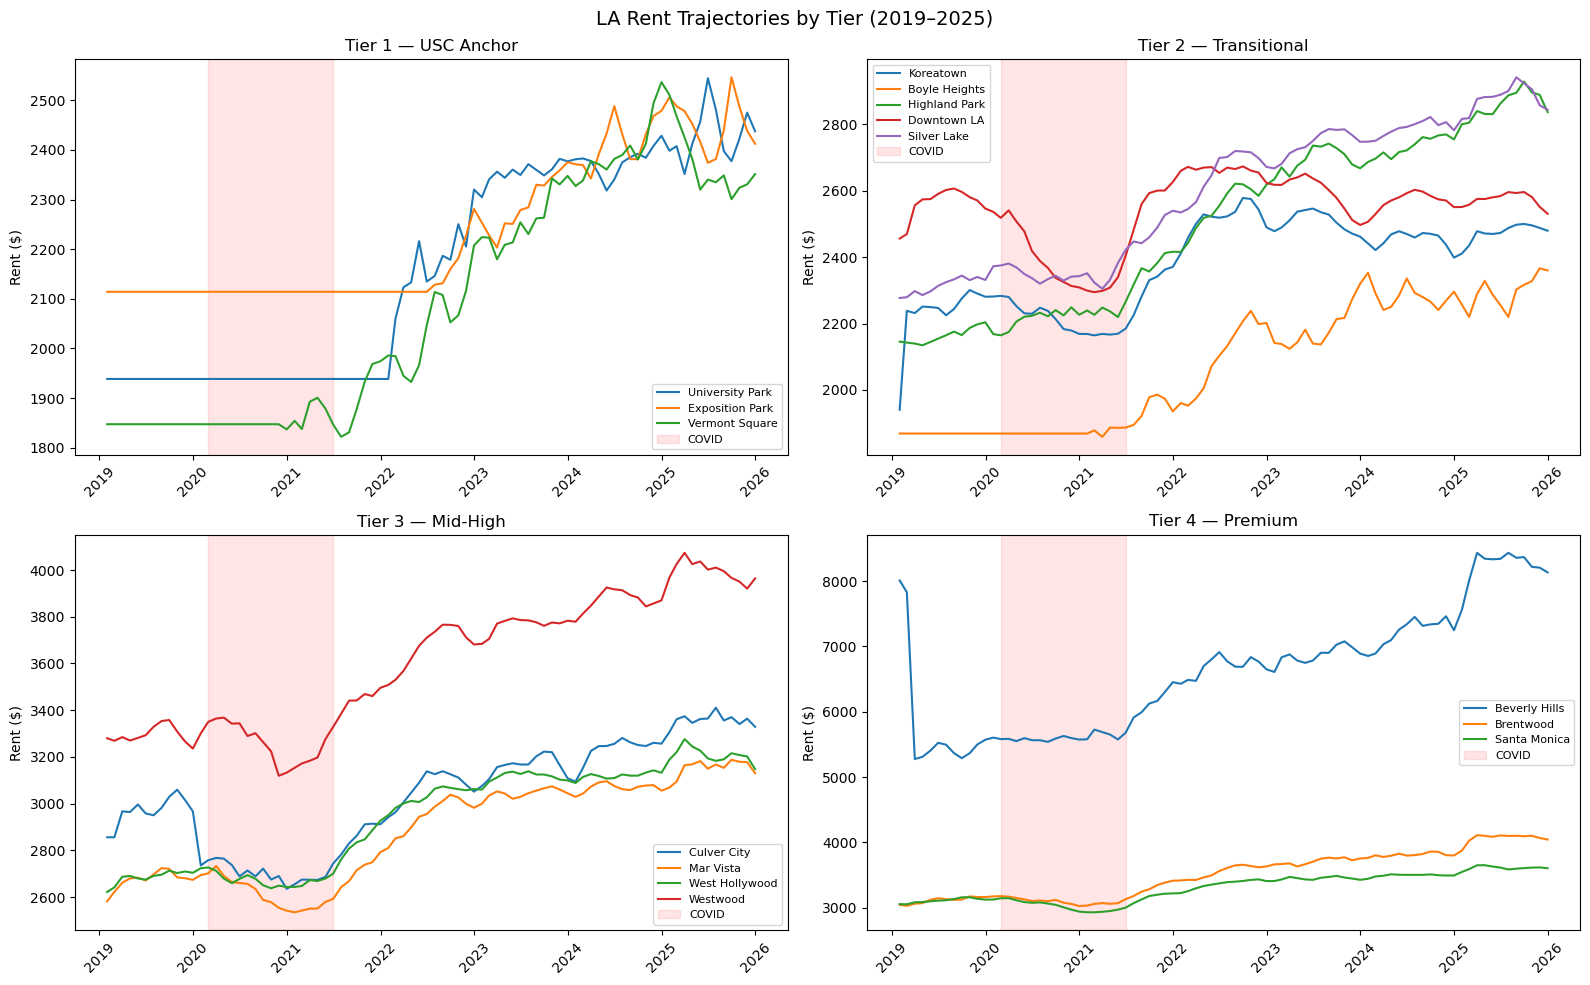

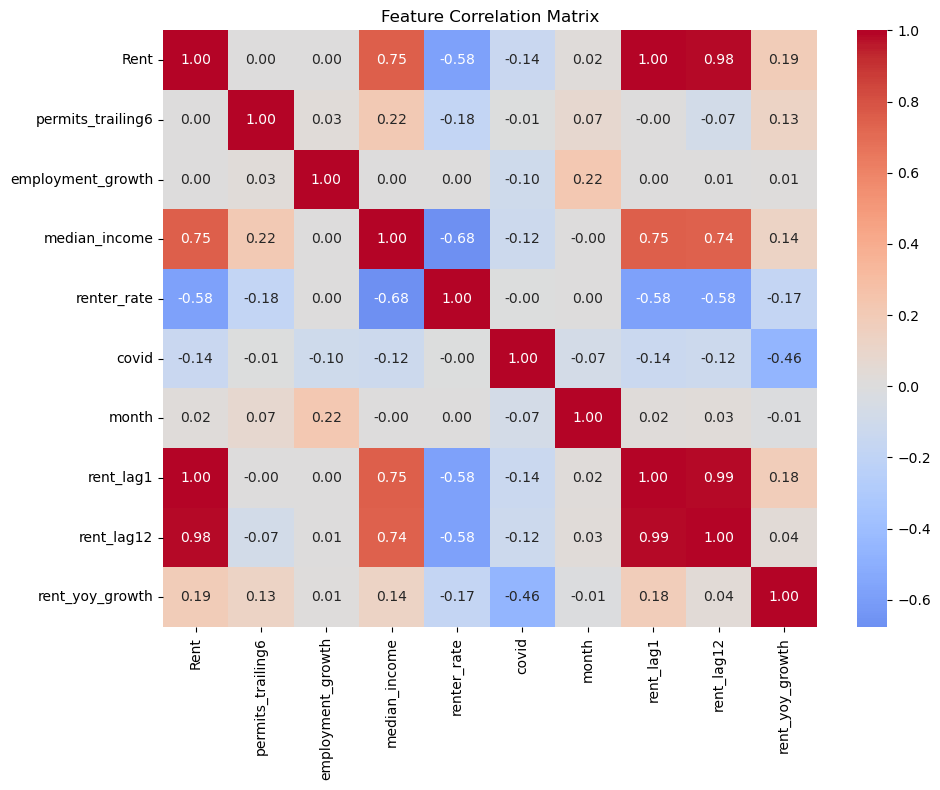

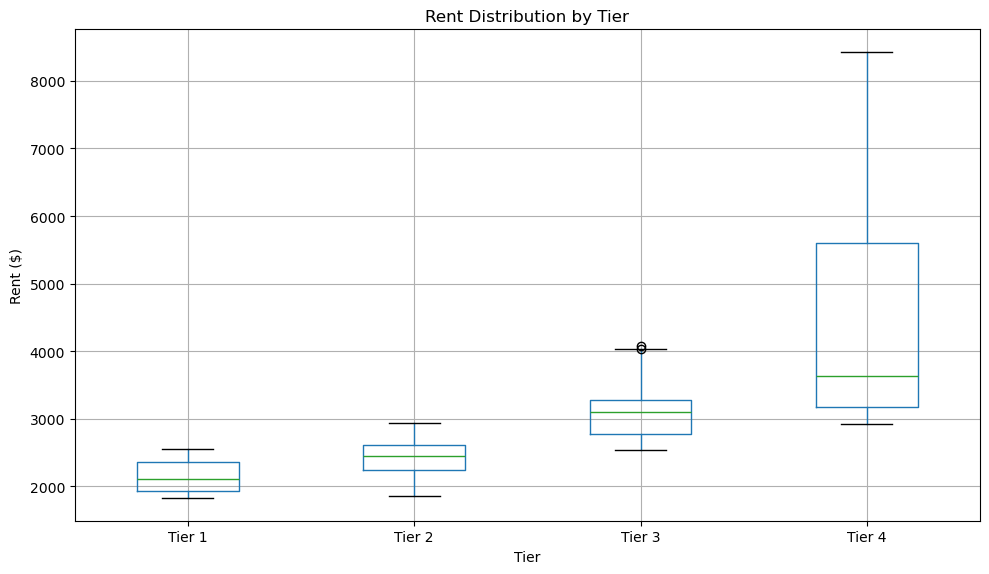

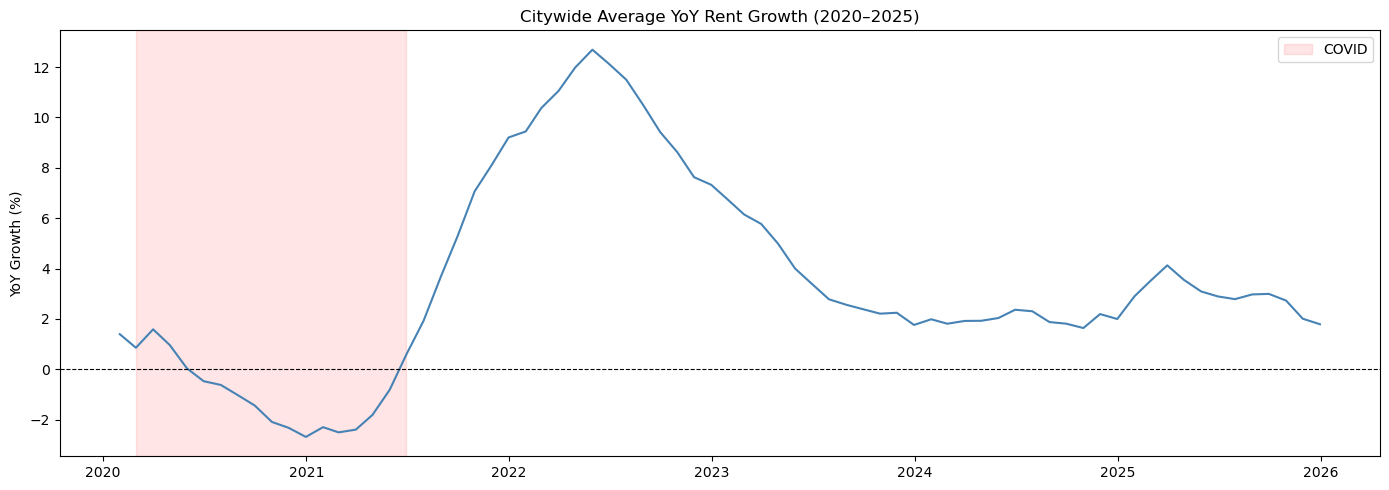

All EDA plots saved.


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

master = pd.read_csv('/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/data/processed/master.csv')
master['Date'] = pd.to_datetime(master['Date'])

# Fix the 22 NaNs
master['employment_growth'] = master['employment_growth'].fillna(0)

# ── Plot 1: Rent trajectories by neighborhood tier ────────────────────────────
tiers = {
    'Tier 1 — USC Anchor':      ['University Park', 'Exposition Park', 'Vermont Square'],
    'Tier 2 — Transitional':    ['Koreatown', 'Boyle Heights', 'Highland Park', 'Downtown LA', 'Silver Lake'],
    'Tier 3 — Mid-High':        ['Culver City', 'Mar Vista', 'West Hollywood', 'Westwood'],
    'Tier 4 — Premium':         ['Beverly Hills', 'Brentwood', 'Santa Monica']
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (tier_name, neighborhoods) in enumerate(tiers.items()):
    ax = axes[i]
    tier_data = master[master['Neighborhood'].isin(neighborhoods)]
    for n in neighborhoods:
        nd = tier_data[tier_data['Neighborhood'] == n]
        ax.plot(nd['Date'], nd['Rent'], label=n)
    ax.axvspan('2020-03-01', '2021-06-30', alpha=0.1, color='red', label='COVID')
    ax.set_title(tier_name)
    ax.legend(fontsize=8)
    ax.set_ylabel('Rent ($)')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('LA Rent Trajectories by Tier (2019–2025)', fontsize=14)
plt.tight_layout()
plt.savefig('/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/visualizations/eda_rent_trajectories.png', dpi=150)
plt.show()

# ── Plot 2: Correlation heatmap ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
numeric_cols = ['Rent', 'permits_trailing6', 'employment_growth',
                'median_income', 'renter_rate', 'covid', 'month',
                'rent_lag1', 'rent_lag12', 'rent_yoy_growth']
corr = master[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/visualizations/eda_correlation.png', dpi=150)
plt.show()

# ── Plot 3: Rent distribution by tier ────────────────────────────────────────
master['Tier'] = master['Neighborhood'].map({
    **{n: 'Tier 1' for n in tiers['Tier 1 — USC Anchor']},
    **{n: 'Tier 2' for n in tiers['Tier 2 — Transitional']},
    **{n: 'Tier 3' for n in tiers['Tier 3 — Mid-High']},
    **{n: 'Tier 4' for n in tiers['Tier 4 — Premium']},
})

fig, ax = plt.subplots(figsize=(10, 6))
master.boxplot(column='Rent', by='Tier', ax=ax)
ax.set_title('Rent Distribution by Tier')
ax.set_xlabel('Tier')
ax.set_ylabel('Rent ($)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/visualizations/eda_rent_by_tier.png', dpi=150)
plt.show()

# ── Plot 4: YoY rent growth over time (citywide average) ─────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
citywide = master.groupby('Date')['rent_yoy_growth'].mean()
ax.plot(citywide.index, citywide.values, color='steelblue')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-30'),
           alpha=0.1, color='red', label='COVID')
ax.set_title('Citywide Average YoY Rent Growth (2020–2025)')
ax.set_ylabel('YoY Growth (%)')
ax.legend()
plt.tight_layout()
plt.savefig('/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/visualizations/eda_yoy_growth.png', dpi=150)
plt.show()

print("All EDA plots saved.")

In [42]:
master_model = master[master['Date'] >= '2020-01-31'].copy()
master_model = master_model.dropna(subset=['rent_lag1', 'rent_lag12', 'rent_yoy_growth'])

print(f"Training shape: {master_model.shape}")
print(f"Missing values:\n{master_model.isnull().sum()}")

Training shape: (1584, 12)
Missing values:
Neighborhood         0
Date                 0
Rent                 0
permits_trailing6    0
employment_growth    0
median_income        0
renter_rate          0
covid                0
month                0
rent_lag1            0
rent_lag12           0
rent_yoy_growth      0
dtype: int64


In [43]:
master_model.to_csv(
    '/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/data/processed/master_model.csv',
    index=False
)
print(f"Saved master_model.csv: {master_model.shape}")

Saved master_model.csv: (1584, 12)


In [44]:
print(f"Shape: {master_model.shape}")
print(f"Date range: {master_model['Date'].min()} to {master_model['Date'].max()}")
print(f"Columns: {list(master_model.columns)}")
print(f"Missing values:\n{master_model.isnull().sum()}")
print(f"\nSample:\n{master_model.head(3)}")

Shape: (1584, 12)
Date range: 2020-01-31 to 2025-12-31
Columns: ['Neighborhood', 'Date', 'Rent', 'permits_trailing6', 'employment_growth', 'median_income', 'renter_rate', 'covid', 'month', 'rent_lag1', 'rent_lag12', 'rent_yoy_growth']
Missing values:
Neighborhood         0
Date                 0
Rent                 0
permits_trailing6    0
employment_growth    0
median_income        0
renter_rate          0
covid                0
month                0
rent_lag1            0
rent_lag12           0
rent_yoy_growth      0
dtype: int64

Sample:
     Neighborhood        Date         Rent  permits_trailing6  \
12  Beverly Hills  2020-01-31  5603.961620               41.0   
13  Beverly Hills  2020-02-29  5581.318853               70.0   
14  Beverly Hills  2020-03-31  5584.722929               96.0   

    employment_growth  median_income  renter_rate  covid  month    rent_lag1  \
12          -1.435188      133923.98       0.3615      0      1  5571.475151   
13           0.797571      133